# Notebook 03 — Features Estructurales

**Notebook:** `03_structural_features.ipynb`  
**TFM:** Bioinformática estructural — Familia RAS  
**Objetivo:** Calcular SASA, distancia al sitio activo y conservación evolutiva para los 166 residuos del dominio G de KRAS, HRAS y NRAS; integrar todo en la tabla maestra `master_features.csv`.

---

## Contexto biológico

### ¿Qué es la SASA?

La **SASA** (*Solvent Accessible Surface Area*, área superficial accesible al solvente) es la fracción de la superficie de un residuo aminoacídico que puede estar en contacto con moléculas de agua del entorno. Se calcula haciendo rodar una esfera-sonda de radio 1.4 Å (radio del agua) sobre la superficie de Van der Waals de la proteína.

- **SASA absoluta** (sasa_abs): área en Å² accesible al solvente para ese residuo en la estructura cristalizada.
- **SASA relativa** (sasa_rel): cociente entre la SASA absoluta y la SASA máxima posible para ese aminoácido (calculada en un tripéptido de referencia extendido Gly-X-Gly). Un valor de 0 significa residuo totalmente enterrado; valores próximos a 1 (o incluso >1 por aproximaciones) significan residuo completamente expuesto.

**Relevancia funcional:** los residuos del sitio activo suelen estar *enterrados* (SASA_rel < 0.25) porque la cavidad de unión del GTP queda en el interior de la proteína. Un residuo enterrado que muta puede alterar el *packing* hidrofóbico o crear impedimentos estéricos sin cambiar la exposición superficial, lo que explica por qué muchos oncogenes mutan en posiciones con SASA baja.

Existen dos métodos principales:
- **DSSP** (*Dictionary of Secondary Structure of Proteins*): usa el algoritmo de Lee & Richards para calcular SASA a la vez que asigna estructura secundaria. Es el método estándar en cristalografía.
- **Shrake-Rupley**: coloca puntos uniformemente distribuidos sobre la esfera de cada átomo y cuenta los que no son ocluidos por átomos vecinos. Es más rápido y no requiere el ejecutable DSSP.

En este notebook se usa la implementación de BioPython que delega en DSSP si está disponible, y usa Shrake-Rupley como alternativa robusta.

### ¿Qué es el sitio activo de RAS?

Las proteínas RAS son **GTPasas pequeñas**: catalizan la hidrólisis de GTP a GDP liberando fosfato inorgánico. El cambio GTP→GDP actúa como interruptor molecular: RAS-GTP está activo y promueve proliferación celular; RAS-GDP está inactivo.

El **sitio activo** comprende los átomos del nucleótido (GDP o GTP) y del ion Mg²⁺ coordinador. Las regiones proteicas que definen el sitio activo son:

| Región | Residuos KRAS | Función |
|--------|---------------|---------|
| P-loop (G1) | 10-17 | Une el fosfato del nucleótido |
| Switch I (G2) | 30-38 | Cambia conformación al hidrolizar GTP |
| Switch II (G3) | 60-76 | Q61 catalítico; interacción con GAP |
| NKxD (G4) | 116-119 | Reconocimiento de la base guanina |
| SAK (G5) | 145-147 | Segunda región de especificidad de guanina |


### ¿Por qué calculamos la distancia al sitio activo?

La **distancia mínima de átomos pesados** (átomos no-hidrógeno) entre un residuo y los átomos del ligando nos da una medida objetiva de la proximidad espacial al sitio de catálisis. Usamos la distancia mínima (en lugar de la distancia entre centros de masa) porque:
1. Mejor refleja el contacto potencial real entre residuo y ligando.
2. Es sensible a la orientación de la cadena lateral (que puede extenderse hacia el ligando).
3. Es la definición usada en estudios de redes de contacto proteína-ligando.

**Criterio biológico:** residuos a < 5 Å del sitio activo forman parte de la primera esfera de coordinación y su mutación impacta directamente en la catálisis o en la afinidad por el nucleótido.

### ¿Qué es la entropía de Shannon en un MSA?

La **entropía de Shannon** mide la variabilidad de una columna del alineamiento múltiple (MSA). Para una columna con frecuencias de aminoácidos $p_1, p_2, ..., p_k$:

$$H = -\sum_{i} p_i \log_2(p_i)$$

- H = 0: la columna es completamente conservada (todos los organismos/isoformas tienen el mismo aminoácido).
- H = log₂(20) ≈ 4.32 bits: máxima entropía (todos los aminoácidos son igualmente frecuentes).


---

## Estructura del notebook

1. Carga de configuración y datos del Hito 2
2. Cálculo de SASA por residuo (3 genes × 3 PDBs)
3. Cálculo de distancia al sitio activo
4. Cálculo de entropía de Shannon desde el MSA
5. Guardado de tablas intermedias
6. Verificaciones biológicas
7. Construcción de la tabla maestra
8. Guardado y visualización
9. Resumen estadístico

## Inputs esperados

- `data/processed/cosmic_curated.csv`
- `data/processed/position_map.csv`
- `data/processed/recurrent_positions.csv`
- PDBs en `data/external/pdb/` o descargables desde RCSB

---
## 1. Configuración y carga de datos

In [37]:
# ============================================================
# CHUNK 1.1: Importaciones y configuración general
# ============================================================

import math          
import sys           
import warnings      
from pathlib import Path 

import numpy as np  
import pandas as pd 

from Bio import AlignIO

from tfm_ras.config import load_config, project_root

from tfm_ras.structural import (
    MASTER_COLUMNS,
    compute_sasa,
    distance_to_active_site,
    fetch_pdb,
    get_active_site_atoms,
    merge_features,
    parse_structure,
    plot_features_overview,
    shannon_entropy_per_position,
)

# Supprimimos los warnings de BioPython sobre átomos con ocupancia alternativa
# (muy comunes en estructuras de alta resolución como 3K8Y a 1.30 Å).
warnings.filterwarnings("ignore", category=UserWarning, module="Bio")

# Verificamos la versión de Python instalada
print(f"Python {sys.version}")
print("Importaciones completadas correctamente.")

Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:58:53) [Clang 19.1.7 ]
Importaciones completadas correctamente.


In [38]:
# ============================================================
# CHUNK 1.2: Carga de la configuración del proyecto
# ============================================================

ROOT = project_root()
print(f"Raíz del proyecto: {ROOT}")

CFG = load_config(ROOT / 'configs' / 'config.yaml')

PROCESSED_DIR = ROOT / "data" / "processed"  
PDB_DIR = ROOT / "data" / "external" / "pdb" 
FIGURES_DIR = ROOT / "figures"               

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)  
FIGURES_DIR.mkdir(parents=True, exist_ok=True)   

# Extraemos los parámetros de configuración relevantes para este notebook.
members_cfg = CFG["family"]["members"] 

# Construimos el mapa gen → PDB_ID usando el PDB primario de cada gen.
# KRAS → 4OBE (GDP-bound, resolución 1.24 Å)
# HRAS → 3K8Y (GppNHp-bound, resolución 1.30 Å)
# NRAS → 5UHV (GppNHp-bound, resolución 1.67 Å)

PDB_BY_GENE = {
    gene: members_cfg[gene]["pdbs"]["primary"]["id"] 
    for gene in ("KRAS", "HRAS", "NRAS")             
}

print("\nMapa gen → PDB primario:")
for gene, pdb_id in PDB_BY_GENE.items(): 
    ligand = members_cfg[gene]["pdbs"]["primary"].get("ligand", "N/A") 
    res = members_cfg[gene]["pdbs"]["primary"].get("resolution_angstrom", "N/A") 
    print(f"  {gene}: {pdb_id}  (ligando: {ligand}, resolución: {res} Å)")

# Extraemos los hotspots oncogénicos desde la configuración.
hotspots = CFG["hotspots"]  
hotspot_positions = [h["position"] for h in hotspots] 
print(f"\nHotspots oncogénicos a verificar: {hotspot_positions}")

Raíz del proyecto: /Users/rachi/Desktop/TFM/tfm_ras_mutations

Mapa gen → PDB primario:
  KRAS: 4OBE  (ligando: GDP, resolución: 1.24 Å)
  HRAS: 3K8Y  (ligando: GppNHp, resolución: 1.3 Å)
  NRAS: 5UHV  (ligando: GppNHp, resolución: 1.67 Å)

Hotspots oncogénicos a verificar: [12, 13, 61, 146, 117, 59]


In [39]:
# ============================================================
# CHUNK 1.3: Carga de datos generados en los hitos anteriores
# ============================================================

# cosmic_curated.csv contiene las mutaciones somáticas missense de KRAS, HRAS y NRAS
# filtradas, deduplicadas y estructuradas por el notebook 01.
# Columnas relevantes: gene, position, wt_aa, mut_aa, hgvs_p, sample_count
cosmic_curated_path = PROCESSED_DIR / "cosmic_curated.csv"  
mutations = pd.read_csv(cosmic_curated_path)  
print(f"Mutaciones cargadas: {len(mutations)} filas")
print(f"  Columnas: {list(mutations.columns)}")
print(f"  Mutaciones por gen:\n{mutations['gene'].value_counts().to_string()}")

# position_map.csv traduce entre posiciones en KRAS, HRAS, NRAS y posición en el MSA.
# Columnas: msa_position, kras_position, hras_position, nras_position,
#           kras_aa, hras_aa, nras_aa, conserved
position_map_path = PROCESSED_DIR / "position_map.csv" 
position_map = pd.read_csv(position_map_path)  
print(f"\nMapa de posiciones cargado: {len(position_map)} columnas del MSA")
print(f"  Columnas: {list(position_map.columns)}")

# msa_ras.fasta contiene el alineamiento múltiple de las tres isoformas RAS.
# Se usa para calcular la entropía de Shannon por posición.
msa_path = PROCESSED_DIR / "msa_ras.fasta"

msa = AlignIO.read(str(msa_path), "fasta") 
print(f"\nMSA cargado:")
print(f"  Número de secuencias: {len(msa)}")
print(f"  Longitud del alineamiento: {msa.get_alignment_length()} columnas")
for record in msa: 
    print(f"  - {record.id}: {len(str(record.seq).replace('-', ''))} residuos (sin gaps)")

# recurrent_positions.csv contiene las posiciones recurrentemente mutadas
recurrent_path = PROCESSED_DIR / "recurrent_positions.csv"
if recurrent_path.exists():
    recurrent = pd.read_csv(recurrent_path) 
    print(f"\nPosiciones recurrentes cargadas: {len(recurrent)} posiciones")
else:
    recurrent = None  # None es el valor centinela Python para "dato no disponible"
    print("\nFichero recurrent_positions.csv no encontrado (no es obligatorio para este hito).")

Mutaciones cargadas: 469 filas
  Columnas: ['gene', 'uniprot_id', 'position', 'wt_aa', 'mut_aa', 'hgvs_p', 'sample_count', 'tumor_types', 'primary_tissues', 'cosmic_version']
  Mutaciones por gen:
gene
KRAS    207
NRAS    133
HRAS    129

Mapa de posiciones cargado: 189 columnas del MSA
  Columnas: ['msa_position', 'kras_position', 'hras_position', 'nras_position', 'kras_aa', 'hras_aa', 'nras_aa', 'conserved']

MSA cargado:
  Número de secuencias: 3
  Longitud del alineamiento: 189 columnas
  - KRAS: 189 residuos (sin gaps)
  - HRAS: 189 residuos (sin gaps)
  - NRAS: 189 residuos (sin gaps)

Posiciones recurrentes cargadas: 6 posiciones


---
## 2. Parseo de estructuras PDB

### ¿Qué es un fichero PDB y la jerarquía SMCRA?

Un fichero PDB (*Protein Data Bank*) contiene las coordenadas atómicas de una proteína obtenidas por cristalografía de rayos X, crioEM u otras técnicas. BioPython organiza esta información en una jerarquía de 5 niveles llamada **SMCRA**:

```
Structure (S)  → todo el fichero PDB
  Model (M)    → habitualmente 1 modelo en cristalografía; varios en NMR
    Chain (C)  → cadena polipeptídica (A, B, C...); la mayoría de RAS tiene cadena A
      Residue (R) → aminoácido o heteroátomo (ligando, agua, ion)
        Atom (A)  → átomo individual con coordenadas x, y, z
```

Los **heteroátomos** (HETATM en el PDB) incluyen:
- El nucleótido GDP/GTP o su análogo GppNHp (ligando que marca el sitio activo)
- El ion Mg²⁺ coordinador (esencial para la catálisis)
- Moléculas de agua cristalográfica

La función `parse_structure()` de nuestro módulo usa BioPython para leer el fichero PDB y devuelve el objeto `Structure` listo para ser analizado.

In [40]:
# ============================================================
# CHUNK 2.1: Parseo de los tres ficheros PDB
# ============================================================

# Diccionario donde almacenaremos los objetos Model de BioPython,
structures = {}  # {"KRAS": <Model>, "HRAS": <Model>, "NRAS": <Model>}
structures_full = {}  # {"KRAS": <Model>, "HRAS": <Model>, "NRAS": <Model>}

print("Parseando estructuras PDB...")
print("-" * 50)

for gene, pdb_id in PDB_BY_GENE.items():
    pdb_path = PDB_DIR / f"{pdb_id}.pdb" 
     # Si el fichero PDB no existe localmente, lo descargamos desde RCSB PDB.
    # Esto garantiza que el notebook funciona incluso si los PDBs no están cacheados.
    if not pdb_path.exists():
        print(f"  {pdb_id}: descargando desde RCSB PDB...")
        pdb_path = fetch_pdb(pdb_id, PDB_DIR)

    # parse_structure() lee el fichero PDB y devuelve el primer Model de BioPython.
    # Un Model (nivel 2 de SMCRA) contiene todas las cadenas (Chain) del cristal.
    # En estructuras de rayos X hay un único modelo; en RMN puede haber varios.

    structure_full = parse_structure(pdb_path)  # primer Model de la jerarquía SMCRA
    structures_full[gene] = structure_full 

    # Creamos una copia con sola la cadena A para los análisis posteriores.
    structure = parse_structure(pdb_path)
    chains_to_remove = [c.id for c in structure.get_chains() if c.id != 'A']
    for chain_id in chains_to_remove:
        structure.detach_child(chain_id)

    # Guardamos el modelo en el diccionario, indexado por nombre de gen.
    structures[gene] = structure  

    # Inspeccionamos el modelo para verificar que se ha cargado correctamente.
    chains = list(structure.get_chains())  
    chain_ids = [c.id for c in chains]  

    # Contamos los residuos aminoacídicos de la cadena principal (cadena 'A').
    # residue.id[0] == ' ' distingue aminoácidos de heteroátomos (HETATM)
    # y residuos de agua ('W'); el espacio indica residuo polipeptídico estándar.
    main_chain = structure['A']  
    amino_residues = [r for r in main_chain if r.id[0] == ' ']  # solo aminoácidos
    hetatm_residues = [r for r in structure.get_residues() 
                       if r.id[0].startswith('H_')]  # heteroátomos

    print(f"  {gene} ({pdb_id}):")
    print(f"    Cadenas: {chain_ids}")
    print(f"    Residuos aminoacídicos (cadena A): {len(amino_residues)}")
    print(f"    Heteroátomos (ligandos, iones) (cadena A): {len(hetatm_residues)}")
    for r in hetatm_residues:
        print(f"      - {r.resname} ID: {r.id}")

print("-" * 50)
print(f"Total estructuras cargadas: {len(structures)}")


Parseando estructuras PDB...
--------------------------------------------------
  KRAS (4OBE):
    Cadenas: ['A']
    Residuos aminoacídicos (cadena A): 169
    Heteroátomos (ligandos, iones) (cadena A): 2
      - GDP ID: ('H_GDP', 201, ' ')
      - MG ID: ('H_MG', 202, ' ')
  HRAS (3K8Y):
    Cadenas: ['A']
    Residuos aminoacídicos (cadena A): 166
    Heteroátomos (ligandos, iones) (cadena A): 6
      - GNP ID: ('H_GNP', 528, ' ')
      - CA ID: ('H_CA', 167, ' ')
      - MG ID: ('H_MG', 168, ' ')
      - CA ID: ('H_CA', 169, ' ')
      - MG ID: ('H_MG', 170, ' ')
      - ACT ID: ('H_ACT', 719, ' ')
  NRAS (5UHV):
    Cadenas: ['A']
    Residuos aminoacídicos (cadena A): 166
    Heteroátomos (ligandos, iones) (cadena A): 3
      - GNP ID: ('H_GNP', 201, ' ')
      - MG ID: ('H_MG', 202, ' ')
      - GOL ID: ('H_GOL', 203, ' ')
--------------------------------------------------
Total estructuras cargadas: 3


---
## 3. Extracción del sitio activo

### ¿Qué átomos forman el sitio activo de RAS?

La función `get_active_site_atoms()` extrae los átomos de:
1. **El nucleótido de guanina** (GDP en 4OBE; GppNHp en 3K8Y y 5UHV): átomo con nombre de residuo GDP/GTP/GNP/GCP o similar.
2. **El ion Mg²⁺** (MG en la nomenclatura PDB): cofactor metálico que coordina los fosfatos del nucleótido y es indispensable para la catálisis.

Estos átomos definen la geometría del sitio activo y son la referencia para calcular distancias de todos los residuos proteicos.

In [41]:
# ============================================================
# CHUNK 3.1: Extracción de átomos del sitio activo
# ============================================================

# Diccionario donde almacenaremos los átomos del sitio activo para cada gen.
active_site_atoms_by_gene = {} 

print("Extrayendo átomos del sitio activo...")
print("-" * 50)

for gene, structure in structures.items():  # iteramos sobre el diccionario de estructuras
    # get_active_site_atoms() busca en la estructura los heteroátomos que forman
    # el sitio activo: el nucleótido (GDP/GTP/GppNHp) y el ion Mg2+.
    # Devuelve una lista de objetos Atom de BioPython.
    active_atoms = get_active_site_atoms(structure) 
    active_site_atoms_by_gene[gene] = active_atoms

    residue_names = set(a.get_parent().resname for a in active_atoms)  # nombres únicos

    pdb_id = PDB_BY_GENE[gene]  # obtenemos el ID del PDB correspondiente al gen
    print(f"  {gene} ({pdb_id}):")
    print(f"    Átomos del sitio activo: {len(active_atoms)}")
    print(f"    Nombres de residuos (HETATM): {sorted(residue_names)}")

    # Verificamos que se ha encontrado al menos 1 átomo del sitio activo.
    assert len(active_atoms) > 0, (
        f"ERROR: no se encontraron átomos del sitio activo en {gene} ({pdb_id}). "
        f"Verifica que el PDB contiene GDP/GTP/GppNHp y MG."
    )

print("-" * 50)
print("Sitios activos extraídos correctamente.")

Extrayendo átomos del sitio activo...
--------------------------------------------------
  KRAS (4OBE):
    Átomos del sitio activo: 38
    Nombres de residuos (HETATM): ['GDP', 'MG']
  HRAS (3K8Y):
    Átomos del sitio activo: 33
    Nombres de residuos (HETATM): ['GNP', 'MG']
  NRAS (5UHV):
    Átomos del sitio activo: 33
    Nombres de residuos (HETATM): ['GNP', 'MG']
--------------------------------------------------
Sitios activos extraídos correctamente.


---
## 4. Cálculo de SASA por residuo

Para cada gen calculamos la SASA absoluta (Å²) y relativa de todos los residuos del dominio G (posiciones 1-166). El DataFrame resultante tiene columnas `position`, `residue`, `sasa_abs`, `sasa_rel`.

In [42]:
# ============================================================
# CHUNK 4.1: Cálculo de SASA para los tres genes
# ============================================================

# Lista donde acumularemos los DataFrames de SASA de los tres genes.
sasa_frames = [] 

print("Calculando SASA por residuo con método ...") 
print("-" * 60)

method_printed = False

for gene, structure in structures.items():  # iteramos sobre los tres genes
    # compute_sasa() aplica el algoritmo de Shrake-Rupley (o DSSP si está disponible) a la estructura y devuelve un DataFrame con las columnas:
    #   position  : número de residuo en la secuencia (1-based, numeración UniProt)
    #   residue   : código de 3 letras del aminoácido (e.g. "GLY", "GLN")
    #   sasa_abs  : área accesible al solvente en Angstroms cuadrados
    #   sasa_rel  : SASA normalizada por la SASA máxima del aminoácido (0-1)
    sasa_df, method_used = compute_sasa(structure)  

    if not method_printed:
        print(f"Método utilizado: {method_used}")
        print("-" * 60)
        method_printed = True

    sasa_df["gene"] = gene 

    sasa_frames.append(sasa_df) 

    # Mostramos estadísticas descriptivas básicas para inspección visual.
    print(f"\n  {gene}: {len(sasa_df)} residuos calculados")
    print(f"    SASA relativa — media: {sasa_df['sasa_rel'].mean():.3f}, "
          f"min: {sasa_df['sasa_rel'].min():.3f}, max: {sasa_df['sasa_rel'].max():.3f}")

    # Mostramos los 5 residuos más enterrados (SASA_rel más baja) como ejemplo
    top_buried = sasa_df.sort_values("sasa_rel").head(5)
    
    # Mostramos los 5 residuos más expuestos (SASA_rel más alta)
    top_exposed = sasa_df.sort_values("sasa_rel", ascending=False).head(5)
    
    print(f"    Top 5 residuos más enterrados:")

    for row in top_buried.itertuples(index=False): 
        print(f"      Pos {row.position:3d} ({row.residue}): SASA_rel = {row.sasa_rel:.3f}")

    print(f"    Top 5 residuos más expuestos:")
    for row in top_exposed.itertuples(index=False):  
        print(f"      Pos {row.position:3d} ({row.residue}): SASA_rel = {row.sasa_rel:.3f}")


print("-" * 60)

sasa_all = pd.concat(sasa_frames, ignore_index=True)  # combina los 3 DataFrames
print(f"\nDataFrame de SASA combinado: {len(sasa_all)} filas")
print(f"Columnas: {list(sasa_all.columns)}")
# .value_counts() cuenta filas por gene para verificar que los 3 genes están presentes
print(f"Filas por gen:\n{sasa_all['gene'].value_counts().to_string()}")


Calculando SASA por residuo con método ...
------------------------------------------------------------
Método utilizado: Shrake-Rupley
------------------------------------------------------------

  KRAS: 169 residuos calculados
    SASA relativa — media: 0.138, min: 0.000, max: 0.643
    Top 5 residuos más enterrados:
      Pos   7 (V): SASA_rel = 0.000
      Pos   8 (V): SASA_rel = 0.000
      Pos   6 (L): SASA_rel = 0.000
      Pos  16 (K): SASA_rel = 0.000
      Pos  14 (V): SASA_rel = 0.000
    Top 5 residuos más expuestos:
      Pos  61 (Q): SASA_rel = 0.643
      Pos  31 (E): SASA_rel = 0.607
      Pos 138 (G): SASA_rel = 0.594
      Pos 168 (E): SASA_rel = 0.549
      Pos  88 (K): SASA_rel = 0.511

  HRAS: 166 residuos calculados
    SASA relativa — media: 0.123, min: 0.000, max: 0.594
    Top 5 residuos más enterrados:
      Pos   4 (Y): SASA_rel = 0.000
      Pos   7 (V): SASA_rel = 0.000
      Pos  14 (V): SASA_rel = 0.000
      Pos  15 (G): SASA_rel = 0.000
      Pos  13 (

In [43]:
# ============================================================
# CHUNK 4.2: Verificación de SASA en hotspots oncogénicos
# ============================================================

# Verificamos los valores de SASA en los hotspots oncogénicos G12, G13, Q61, A146, K117 y A59.
# G12 y G13 se espera encontrar enterrados (SASA_rel < 0.25) por su posición en el P-loop.
# Q61 (Switch II) puede mostrar mayor exposición dependiendo del estado del nucleótido.

print("SASA en hotspots oncogénicos (G12, G13, Q61, A146, K117 y A59):")
print("-" * 65)

for gene in ["KRAS", "HRAS", "NRAS"]:
    df = sasa_all[sasa_all["gene"] == gene]
    hotspots_check = df[df["position"].isin([12, 13, 61, 59, 117, 146])]
    print(f"\n{gene}:")
    print(hotspots_check[["position", "residue", "sasa_abs", "sasa_rel"]].to_string(index=False))

print("-" * 65)

SASA en hotspots oncogénicos (G12, G13, Q61, A146, K117 y A59):
-----------------------------------------------------------------

KRAS:
 position residue   sasa_abs  sasa_rel
       12       G   9.927433  0.095456
       13       G   7.039995  0.067692
       59       A  12.819105  0.099373
       61       Q 144.640572  0.642847
      117       K  10.682043  0.045263
      146       A   0.000000  0.000000

HRAS:
 position residue  sasa_abs  sasa_rel
       12       G  1.071459  0.010302
       13       G  0.000000  0.000000
       59       A  0.000000  0.000000
       61       Q 42.335902  0.188160
      117       K  0.000000  0.000000
      146       A  0.000000  0.000000

NRAS:
 position residue  sasa_abs  sasa_rel
       12       G 15.562998  0.149644
       13       G  9.546986  0.091798
       59       A  0.000000  0.000000
       61       Q 38.416023  0.170738
      117       K  0.000000  0.000000
      146       A  0.000000  0.000000
--------------------------------------------

---
## 5. Cálculo de distancia al sitio activo

Para cada residuo calculamos la **distancia mínima de átomos pesados** (no-hidrógeno) al conjunto de átomos del sitio activo. La distancia euclídea entre dos átomos se calcula con `np.linalg.norm(coord_a - coord_b)`, donde `coord_a` y `coord_b` son vectores de 3 coordenadas [x, y, z] en Å.

**¿Por qué distancia mínima y no distancia entre centros de masa?** Porque la cadena lateral de un residuo puede proyectarse hacia el sitio activo aunque el Cα esté más alejado. La distancia mínima captura este efecto de contacto real.

In [44]:
# ============================================================
# CHUNK 5.1: Cálculo de distancia al sitio activo
# ============================================================

# Lista donde acumularemos los DataFrames de distancias de los tres genes.
distance_frames = [] 

print("Calculando distancias al sitio activo...")
print("-" * 50)

for gene in PDB_BY_GENE: 
    structure = structures[gene]             
    active_atoms = active_site_atoms_by_gene[gene]  

    # Calcula la distancia mínima de átomos pesados al sitio activo 
    # y devuelve un DataFrame con las columnas:
    #   position              : número de residuo (numeración UniProt)
    #   residue               : código de 3 letras del aminoácido
    #   min_distance_angstrom : distancia mínima en Angstroms al átomo del sitio activo más cercano
    dist_df = distance_to_active_site(structure, active_atoms)  

    dist_df["gene"] = gene  

    distance_frames.append(dist_df) 

    # Mostramos estadísticas para inspección.
    print(f"\n  {gene}: {len(dist_df)} residuos calculados")
    print(f"    Distancia mínima — media: {dist_df['min_distance_angstrom'].mean():.2f} Å, "
          f"min: {dist_df['min_distance_angstrom'].min():.2f} Å")

    # Mostramos los 5 residuos más cercanos al sitio activo.
    closest = dist_df.sort_values("min_distance_angstrom").head(5) 
    print(f"    Top 5 residuos más cercanos al sitio activo:")
    for row in closest.itertuples(index=False):
        print(f"      Pos {row.position:3d} ({row.residue}): {row.min_distance_angstrom:.2f} Å")
    
    # Mostramos la distancia de los principales hotspots mutacionales.
    all_hotspots = [12, 13, 59, 61, 117, 146]

    print("    Distancia de los hotspots al sitio activo:")
    hotspot_df = dist_df[dist_df["position"].isin(all_hotspots)].sort_values("position")

    for row in hotspot_df.itertuples(index=False):
        print(
            f"      {row.residue}{row.position:3d}: {row.min_distance_angstrom:.2f} Å")

print("-" * 50)

# Combinamos los DataFrames de distancias de los 3 genes en uno solo.
distance_all = pd.concat(distance_frames, ignore_index=True) 
print(f"\nDataFrame de distancias combinado: {len(distance_all)} filas")
print(f"Columnas: {list(distance_all.columns)}")

Calculando distancias al sitio activo...
--------------------------------------------------

  KRAS: 169 residuos calculados
    Distancia mínima — media: 13.25 Å, min: 2.09 Å
    Top 5 residuos más cercanos al sitio activo:
      Pos  17 (S): 2.09 Å
      Pos  16 (K): 2.78 Å
      Pos 146 (A): 2.78 Å
      Pos  13 (G): 2.82 Å
      Pos  18 (A): 2.85 Å
    Distancia de los hotspots al sitio activo:
      G 12: 3.84 Å
      G 13: 2.82 Å
      A 59: 5.35 Å
      Q 61: 10.68 Å
      K117: 3.21 Å
      A146: 2.78 Å

  HRAS: 166 residuos calculados
    Distancia mínima — media: 12.38 Å, min: 2.14 Å
    Top 5 residuos más cercanos al sitio activo:
      Pos  17 (S): 2.14 Å
      Pos  35 (T): 2.16 Å
      Pos  16 (K): 2.63 Å
      Pos  29 (V): 2.69 Å
      Pos  60 (G): 2.78 Å
    Distancia de los hotspots al sitio activo:
      G 12: 3.46 Å
      G 13: 3.10 Å
      A 59: 3.93 Å
      Q 61: 4.15 Å
      K117: 3.28 Å
      A146: 2.84 Å

  NRAS: 166 residuos calculados
    Distancia mínima — med

---
## 6. Cálculo de entropía de Shannon por posición del MSA

### ¿Cómo se calcula la entropía de Shannon en un MSA?

Para cada columna del alineamiento:
1. Contamos la frecuencia de cada aminoácido (excluyendo gaps '-').
2. Calculamos la proporción $p_i$ de cada aminoácido.
3. Aplicamos la fórmula: $H = -\sum_{i} p_i \log_2(p_i)$

En Python: `H = -sum(p * math.log2(p) for p in proportions if p > 0)`

El condicional `if p > 0` es necesario porque `log2(0)` no está definido matemáticamente (el límite cuando p→0 de p·log2(p) es 0, no −∞).

En este TFM el MSA solo tiene 3 secuencias (KRAS, HRAS, NRAS), así que la entropía máxima es log₂(3) ≈ 1.58 bits (si las 3 tienen aminoácidos completamente distintos). Las posiciones con entropía = 0 son perfectamente conservadas en las tres isoformas.

In [45]:
# ============================================================
# CHUNK 6.1: Entropía de Shannon por columna del MSA
# ============================================================

# shannon_entropy_per_position() recibe un objeto MultipleSeqAlignment de BioPython
# y devuelve un DataFrame con una fila por columna del alineamiento:
#   msa_position : índice 1-based de la columna en el MSA
#   entropy_bits : entropía de Shannon en bits (0 = conservado, max ≈ log2(20) para 20 aa)
conservation = shannon_entropy_per_position(msa) 

print(f"Entropías calculadas: {len(conservation)} posiciones del MSA")
print(f"Columnas: {list(conservation.columns)}")
print()

# Estadísticas de los valores de entropía de Shannon
print("Estadísticas de entropía de Shannon:")
print(conservation["entropy_bits"].describe().round(4).to_string()) 

# Posiciones completamente conservadas (H = 0): todos los aminoácidos son iguales.
n_conserved = (conservation["entropy_bits"].eq(0.0)).sum()  # número de posiciones conservadas
n_total = len(conservation)  # total de posiciones en el MSA
print(f"\nPosiciones perfectamente conservadas (H=0): {n_conserved}/{n_total} "
      f"({100*n_conserved/n_total:.1f}%)")

# Mostramos las posiciones con mayor variabilidad (entropía más alta).
# Estas corresponden a residuos divergentes entre isoformas.
print("\nTop 10 posiciones más variables (mayor entropía):")
top_variable = conservation.sort_values("entropy_bits", ascending=False).head(10)  # más variables
print(top_variable.to_string(index=False))

# Verificamos que los hotspots oncogénicos tengan entropía baja.
print("\nEntropía en los hotspots oncogénicos:")

for hp in hotspots:  
    pos = hp["position"]  
    aa = hp["residue"]  

    msa_rows = position_map.loc[position_map["kras_position"].eq(pos)]  

    if msa_rows.empty: 
        print(f"  {aa}{pos}: posición no encontrada en el mapa")
        continue 

    msa_pos = int(msa_rows.iloc[0]["msa_position"]) 

    ent_rows = conservation.loc[conservation["msa_position"].eq(msa_pos)]  
    if ent_rows.empty: 
        print(f"  {aa}{pos} (MSA pos {msa_pos}): no encontrado en conservation")
        continue

    entropy_val = float(ent_rows.iloc[0]["entropy_bits"]) 
    print(f"  {aa}{pos} (MSA pos {msa_pos}): H = {entropy_val:.4f} bits")

Entropías calculadas: 189 posiciones del MSA
Columnas: ['msa_position', 'entropy_bits', 'n_gaps']

Estadísticas de entropía de Shannon:
count    189.0000
mean       0.2186
std        0.4643
min       -0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max        1.5850

Posiciones perfectamente conservadas (H=0): 152/189 (80.4%)

Top 10 posiciones más variables (mayor entropía):
 msa_position  entropy_bits  n_gaps
          178      1.584963       0
          179      1.584963       0
          174      1.584963       0
          184      1.584963       0
          183      1.584963       0
          173      1.584963       0
          176      1.584963       0
          177      1.584963       0
          122      1.584963       0
           95      1.584963       0

Entropía en los hotspots oncogénicos:
  G12 (MSA pos 12): H = -0.0000 bits
  G13 (MSA pos 13): H = -0.0000 bits
  Q61 (MSA pos 61): H = -0.0000 bits
  A146 (MSA pos 146): H = -0.0000 bits
  K117 (MSA pos 117): H

---
## 7. Guardado de tablas intermedias

In [46]:
# ============================================================
# CHUNK 7.1: Guardado de SASA, distancias y conservación
# ============================================================

# Definimos las rutas de salida para cada tabla intermedia.

sasa_out = PROCESSED_DIR / "sasa_per_residue.csv"           # SASA de los 3 genes
distance_out = PROCESSED_DIR / "distance_to_active_site.csv"  # distancias de los 3 genes
conservation_out = PROCESSED_DIR / "conservation_per_msa_position.csv"  # entropías de Shannon

sasa_all.to_csv(sasa_out, index=False)         
distance_all.to_csv(distance_out, index=False)  
conservation.to_csv(conservation_out, index=False) 

print("Tablas intermedias guardadas:")
# Mostramos ruta y tamaño de cada fichero guardado.
for path in (sasa_out, distance_out, conservation_out):  
    size_kb = path.stat().st_size / 1024  
    print(f"  {path.name}: {size_kb:.1f} KB")

# Verificamos que los ficheros se han creado correctamente releyéndolos.
# Si la lectura falla, significa que el guardado no fue correcto.
sasa_check = pd.read_csv(sasa_out)         
distance_check = pd.read_csv(distance_out) 
conservation_check = pd.read_csv(conservation_out)  

print("\nVerificación de integridad:")
print(f"  sasa_per_residue.csv: {len(sasa_check)} filas — OK") 
print(f"  distance_to_active_site.csv: {len(distance_check)} filas — OK")
print(f"  conservation_per_msa_position.csv: {len(conservation_check)} filas — OK")

Tablas intermedias guardadas:
  sasa_per_residue.csv: 19.6 KB
  distance_to_active_site.csv: 14.1 KB
  conservation_per_msa_position.csv: 2.5 KB

Verificación de integridad:
  sasa_per_residue.csv: 501 filas — OK
  distance_to_active_site.csv: 501 filas — OK
  conservation_per_msa_position.csv: 189 filas — OK


---
## 8. Verificaciones biológicas

Antes de construir la tabla maestra, verificamos que los valores calculados son **biológicamente coherentes**. Estas verificaciones son la "prueba de realidad" del análisis: si fallan, indican un error en el código o en los datos de entrada, no resultados inesperados.

### Verificaciones esperadas:
1. **G12 con SASA_rel < 0.25**: la Glicina 12 está enterrada en la cavidad de unión al nucleótido.
2. **G12 < 5 Å del sitio activo** en los 3 genes: G12 está en el P-loop, en contacto directo con el fosfato.
3. **Hotspots con entropía cercana a 0**: posiciones perfectamente conservadas en los tres genes.

In [47]:
# ======================================================================
# CHUNK 8.1: Verificación biológica — SASA de G12
# ======================================================================

print("=" * 60)
print("VERIFICACIÓN 2: G12 debe tener SASA_rel < 0.25 (residuo enterrado)")
print("=" * 60)

for gene in PDB_BY_GENE:
    # Filtramos el DataFrame de SASA para el gen y la posición 12.
    g12_sasa_rows = sasa_all.loc[
        sasa_all["gene"].eq(gene)       # condición 1: gen correcto
        & sasa_all["position"].eq(12)   # condición 2: posición 12 (G12)
    ]

    assert not g12_sasa_rows.empty, (
        f"ERROR: posición G12 no encontrada en la tabla SASA de {gene}."
    )

    g12_sasa_rel = float(g12_sasa_rows.iloc[0]["sasa_rel"])  # SASA relativa de G12

    # Verificación: SASA_rel < 0.25 para G12 (umbral empírico de residuos enterrados).
    assert g12_sasa_rel < 0.25, (
        f"FALLO BIOLÓGICO: {gene} G12 tiene SASA_rel = {g12_sasa_rel:.3f}. "
        f"Esperado < 0.25 (residuo enterrado en el sitio activo)."
    )

    status = "PASS" if g12_sasa_rel < 0.25 else "FAIL"  # resultado de la verificación
    print(f"  {gene} G12: SASA_rel = {g12_sasa_rel:.3f} — {status}")

print()

VERIFICACIÓN 2: G12 debe tener SASA_rel < 0.25 (residuo enterrado)
  KRAS G12: SASA_rel = 0.095 — PASS
  HRAS G12: SASA_rel = 0.010 — PASS
  NRAS G12: SASA_rel = 0.150 — PASS



In [48]:
# ======================================================================
# CHUNK 8.2: Verificación biológica — Distancia al sitio activo de G12
# ======================================================================

print("=" * 60)
print("VERIFICACIÓN 1: G12 debe estar a < 5 Å del sitio activo")
print("=" * 60)

# Verificamos la distancia de G12 al sitio activo en cada gen.
for gene in PDB_BY_GENE:  
    g12_rows = distance_all.loc[
        distance_all["gene"].eq(gene)        # condición 1: fila del gen correcto
        & distance_all["position"].eq(12)    # condición 2: posición 12
    ]

    # Verificamos que encontramos exactamente una fila para G12 en este gen.
    assert not g12_rows.empty, (
        f"ERROR: posición G12 no encontrada en las distancias de {gene}. "
        f"Verifica que la numeración UniProt es correcta."
    )

    g12_distance = float(g12_rows.iloc[0]["min_distance_angstrom"])  # distancia en Å

    # Verificación biológica: G12 debe estar a < 5 Å del sitio activo.
    assert g12_distance < 5.0, (
        f"FALLO BIOLÓGICO: {gene} G12 está a {g12_distance:.2f} Å del sitio activo. "
        f"Esperado < 5.0 Å. Verifica la extracción de átomos del sitio activo."
    )

    status = "PASS" if g12_distance < 5.0 else "FAIL" 
    print(f"  {gene} G12: {g12_distance:.2f} Å — {status}")

print()

VERIFICACIÓN 1: G12 debe estar a < 5 Å del sitio activo
  KRAS G12: 3.84 Å — PASS
  HRAS G12: 3.46 Å — PASS
  NRAS G12: 3.41 Å — PASS



In [49]:
# ======================================================================
# CHUNK 8.3: Verificación biológica — Entropía de los hotspots
# ======================================================================

print("=" * 60)
print("VERIFICACIÓN 3: hotspots deben tener entropía cercana a 0")
print("=" * 60)

# Los hotspots oncogénicos (G12, G13, Q61, A146, K117 y A59) son posiciones funcionalmente irremplazables:
# están perfectamente conservados en las tres isoformas RAS por tanto, su entropía de Shannon en el MSA debe ser muy baja (idealmente = 0).

# Umbral: entropía < 0.1 bits indica alta conservación.
# El MSA de 3 secuencias tiene max H = log2(3) ≈ 1.58 bits.

ENTROPY_THRESHOLD = 0.1  # umbral de entropía para considerar un residuo conservado

for hp in hotspots:  # hp = {"position": 12, "residue": "G"}
    pos = hp["position"]  # posición en KRAS
    aa = hp["residue"]    # aminoácido en código de una letra

    # Buscamos la posición MSA correspondiente a esta posición de KRAS.
    msa_rows = position_map.loc[position_map["kras_position"].eq(pos)]

    if msa_rows.empty:  # si la posición no está en el mapa, saltamos
        print(f"  {aa}{pos}: no encontrado en el mapa posicional — SKIP")
        continue

    msa_pos = int(msa_rows.iloc[0]["msa_position"])  # columna del MSA (1-based)

    # Buscamos la entropía de esa columna del MSA.
    ent_rows = conservation.loc[conservation["msa_position"].eq(msa_pos)]

    if ent_rows.empty:  # si la posición no está en conservation
        print(f"  {aa}{pos}: no encontrado en conservation — SKIP")
        continue

    entropy_val = float(ent_rows.iloc[0]["entropy_bits"])  # entropía en bits

    # Verificamos que la entropía es menor que el umbral.
    is_conserved = entropy_val < ENTROPY_THRESHOLD  # booleano: True si conservado
    status = "PASS" if is_conserved else "WARN"  # no forzamos assert aquí (podría fallar en MSA de 3 seqs)

    print(f"  {aa}{pos} (MSA pos {msa_pos}): H = {entropy_val:.4f} bits — {status}")

print()
print("Verificaciones biológicas completadas.")

VERIFICACIÓN 3: hotspots deben tener entropía cercana a 0
  G12 (MSA pos 12): H = -0.0000 bits — PASS
  G13 (MSA pos 13): H = -0.0000 bits — PASS
  Q61 (MSA pos 61): H = -0.0000 bits — PASS
  A146 (MSA pos 146): H = -0.0000 bits — PASS
  K117 (MSA pos 117): H = -0.0000 bits — PASS
  A59 (MSA pos 59): H = -0.0000 bits — PASS

Verificaciones biológicas completadas.


---
## 9. Construcción de la tabla maestra

La función `merge_features()` combina todas las métricas calculadas en una única tabla con **498 filas** (166 posiciones del dominio G × 3 genes). Esta es la tabla de entrada para el modelo de machine learning del Hito 5.

### Estructura de la tabla maestra

Las columnas definidas en `MASTER_COLUMNS` son exactamente:

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `gene` | str | Nombre del gen (KRAS, HRAS, NRAS) |
| `uniprot_position` | int | Posición del residuo en la secuencia UniProt |
| `msa_position` | int | Columna correspondiente en el MSA |
| `aa_wt` | str | Aminoácido wild-type (código de una letra) |
| `total_samples` | int | Total de muestras COSMIC con mutación en esa posición |
| `top_mutation` | str | Mutación más frecuente (e.g. "G12D") |
| `sasa_abs` | float | SASA absoluta en Å² |
| `sasa_rel` | float | SASA relativa (0 = enterrado, ~1 = expuesto) |
| `dist_active_site_angstrom` | float | Distancia mínima de átomos pesados al sitio activo en Å |
| `shannon_entropy` | float | Entropía de Shannon en bits de la columna MSA |
| `recurrent` | bool | True si la posición tiene mutaciones recurrentes en COSMIC |
| `n_members_mutated` | int | Número de isoformas RAS mutadas en esa posición |

Nota: los DataFrames intermedios (`distance_to_active_site`, `shannon_entropy_per_position`) usan los nombres de columna `min_distance_angstrom` y `entropy_bits`. La función `merge_features()` los renombra internamente a `dist_active_site_angstrom` y `shannon_entropy` al construir la tabla maestra.

In [50]:
# ============================================================
# CHUNK 9.1: Construcción de la tabla maestra con merge_features()
# ============================================================

print("Construyendo tabla maestra...")

master = merge_features(
    mutations,      # mutaciones COSMIC curadas (del Hito 1)
    sasa_all,       # SASA de los 3 genes combinada
    distance_all,   # distancias de los 3 genes combinadas 
    conservation,   # entropía de Shannon por posición MSA
    position_map,   # mapa de equivalencias posicionales entre genes y MSA
)  # devuelve DataFrame con MASTER_COLUMNS

print(f"\nTabla maestra construida:")
print(f"  Filas: {len(master)}")       # esperado: 498 = 166 × 3
print(f"  Columnas: {len(master.columns)}")  # número de features
print(f"  Columnas: {list(master.columns)}")

# Mostramos las primeras filas para inspección visual.
print("\nPrimeras 10 filas de cada gen de la tabla maestra:")
display(master.groupby('gene').head(15))

Construyendo tabla maestra...

Tabla maestra construida:
  Filas: 498
  Columnas: 12
  Columnas: ['gene', 'uniprot_position', 'msa_position', 'aa_wt', 'total_samples', 'top_mutation', 'sasa_abs', 'sasa_rel', 'dist_active_site_angstrom', 'shannon_entropy', 'recurrent', 'n_members_mutated']

Primeras 10 filas de cada gen de la tabla maestra:


,gene,uniprot_position,msa_position,aa_wt,total_samples,top_mutation,sasa_abs,sasa_rel,dist_active_site_angstrom,shannon_entropy,recurrent,n_members_mutated
0,KRAS,1,1,M,0,,101.908176,0.454947,25.777900,-0.0,False,0
1,KRAS,2,2,T,1,p.T2I,21.044599,0.122352,24.258382,-0.0,False,0
2,KRAS,3,3,E,1,p.E3K,72.171544,0.323639,20.156043,-0.0,False,0
3,KRAS,4,4,Y,0,,6.612324,0.025142,18.543821,-0.0,False,0
4,KRAS,5,5,K,6,p.K5E,39.925873,0.169177,17.052413,-0.0,False,0
5,KRAS,6,6,L,2,p.L6H,0.000000,0.000000,13.278990,-0.0,False,0
6,KRAS,7,7,V,2,p.V7A,0.000000,0.000000,11.073938,-0.0,False,0
7,KRAS,8,8,V,4,p.V8I,0.000000,0.000000,6.965781,-0.0,False,0
8,KRAS,9,9,V,4,p.V9D,0.000000,0.000000,7.056784,-0.0,False,0
9,KRAS,10,10,G,14,p.G10R,0.000000,0.000000,5.389509,-0.0,False,1


In [51]:
# ======================================================================
# CHUNK 9.2: Verificación del esquema y completitud de la tabla maestra
# ======================================================================

print("Verificando esquema de la tabla maestra...")
print("-" * 50)

# VERIFICACIÓN DE ESQUEMA: las columnas deben coincidir exactamente con MASTER_COLUMNS.
# MASTER_COLUMNS es una constante definida en structural.py que lista las columnas
# en el orden correcto. Si hay columnas de más o de menos, el assert falla.
assert list(master.columns) == MASTER_COLUMNS, (
    f"Las columnas de la tabla maestra no coinciden con MASTER_COLUMNS.\n"
    f"Esperadas: {MASTER_COLUMNS}\n"
    f"Obtenidas: {list(master.columns)}"
)
print("  Esquema de columnas: PASS")

# VERIFICACIÓN DE COMPLETITUD: debe haber exactamente 498 filas.
# 166 posiciones del dominio G × 3 genes (KRAS, HRAS, NRAS) = 498.
assert len(master) == 498, (
    f"La tabla maestra tiene {len(master)} filas. Esperado: 498 (166 × 3)."
)
print(f"  Número de filas (498 = 166 × 3): PASS")

# VERIFICACIÓN POR GEN: cada gen debe tener exactamente 166 posiciones únicas.
counts_per_gene = master.groupby("gene")["uniprot_position"].nunique().to_dict()
expected_counts = {"KRAS": 166, "HRAS": 166, "NRAS": 166}  # esperado

assert counts_per_gene == expected_counts, (
    f"Número de posiciones por gen incorrecto.\n"
    f"Esperado: {expected_counts}\n"
    f"Obtenido: {counts_per_gene}"
)
print(f"  Posiciones por gen {counts_per_gene}: PASS")

# VERIFICACIÓN DE VALORES NULOS: la tabla maestra no debe tener NaN en columnas clave.
null_counts = master.isnull().sum()  
key_cols = ["sasa_rel", "dist_active_site_angstrom", "shannon_entropy"] 
for col in key_cols: 
    n_null = null_counts.get(col, 0) 
    if n_null > 0: 
        print(f"  AVISO: columna '{col}' tiene {n_null} valores nulos")
    else:
        print(f"  Sin valores nulos en '{col}': PASS")

print("-" * 50)
print("Todas las verificaciones de la tabla maestra completadas.")

Verificando esquema de la tabla maestra...
--------------------------------------------------
  Esquema de columnas: PASS
  Número de filas (498 = 166 × 3): PASS
  Posiciones por gen {'HRAS': 166, 'KRAS': 166, 'NRAS': 166}: PASS
  Sin valores nulos en 'sasa_rel': PASS
  Sin valores nulos en 'dist_active_site_angstrom': PASS
  Sin valores nulos en 'shannon_entropy': PASS
--------------------------------------------------
Todas las verificaciones de la tabla maestra completadas.


---
## 10. Guardado de la tabla maestra

In [52]:
# ============================================================
# CHUNK 10.1: Guardado de master_features.csv
# ============================================================

# Ruta de salida para la tabla maestra.
master_out = PROCESSED_DIR / "master_features.csv"  # ruta de salida

# Guardamos el DataFrame como CSV.
master.to_csv(master_out, index=False, encoding="utf-8") 

print(f"Tabla maestra guardada en: {master_out}")
print(f"  Tamaño: {master_out.stat().st_size / 1024:.1f} KB")

# Releemos el fichero guardado para verificar que se puede cargar correctamente.
master_reload = pd.read_csv(master_out)
print(f"  Verificación tras recarga: {len(master_reload)} filas × {len(master_reload.columns)} columnas — OK")

# Verificamos que los tipos de dato críticos se han preservado correctamente.
# pandas infiere los tipos al leer CSV: float64 para decimales, int64 para enteros.
# Usamos los nombres de columna de MASTER_COLUMNS (después del merge):
#   'dist_active_site_angstrom' (no 'min_distance_angstrom', que es el nombre intermedio)
#   'shannon_entropy' (no 'entropy_bits', que es el nombre del DataFrame de conservación)
print("\nTipos de datos de columnas clave:")
for col in ["uniprot_position", "sasa_rel", "dist_active_site_angstrom", "shannon_entropy"]:
    if col in master_reload.columns:  # verificamos que la columna existe
        print(f"  {col}: {master_reload[col].dtype}")

Tabla maestra guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/master_features.csv
  Tamaño: 40.3 KB
  Verificación tras recarga: 498 filas × 12 columnas — OK

Tipos de datos de columnas clave:
  uniprot_position: int64
  sasa_rel: float64
  dist_active_site_angstrom: float64
  shannon_entropy: float64


---
## 11. Visualización: resumen de features

Generando figura de resumen: 03_features_overview.png
Figura guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/03_features_overview.png
Tamaño del fichero: 717 KB


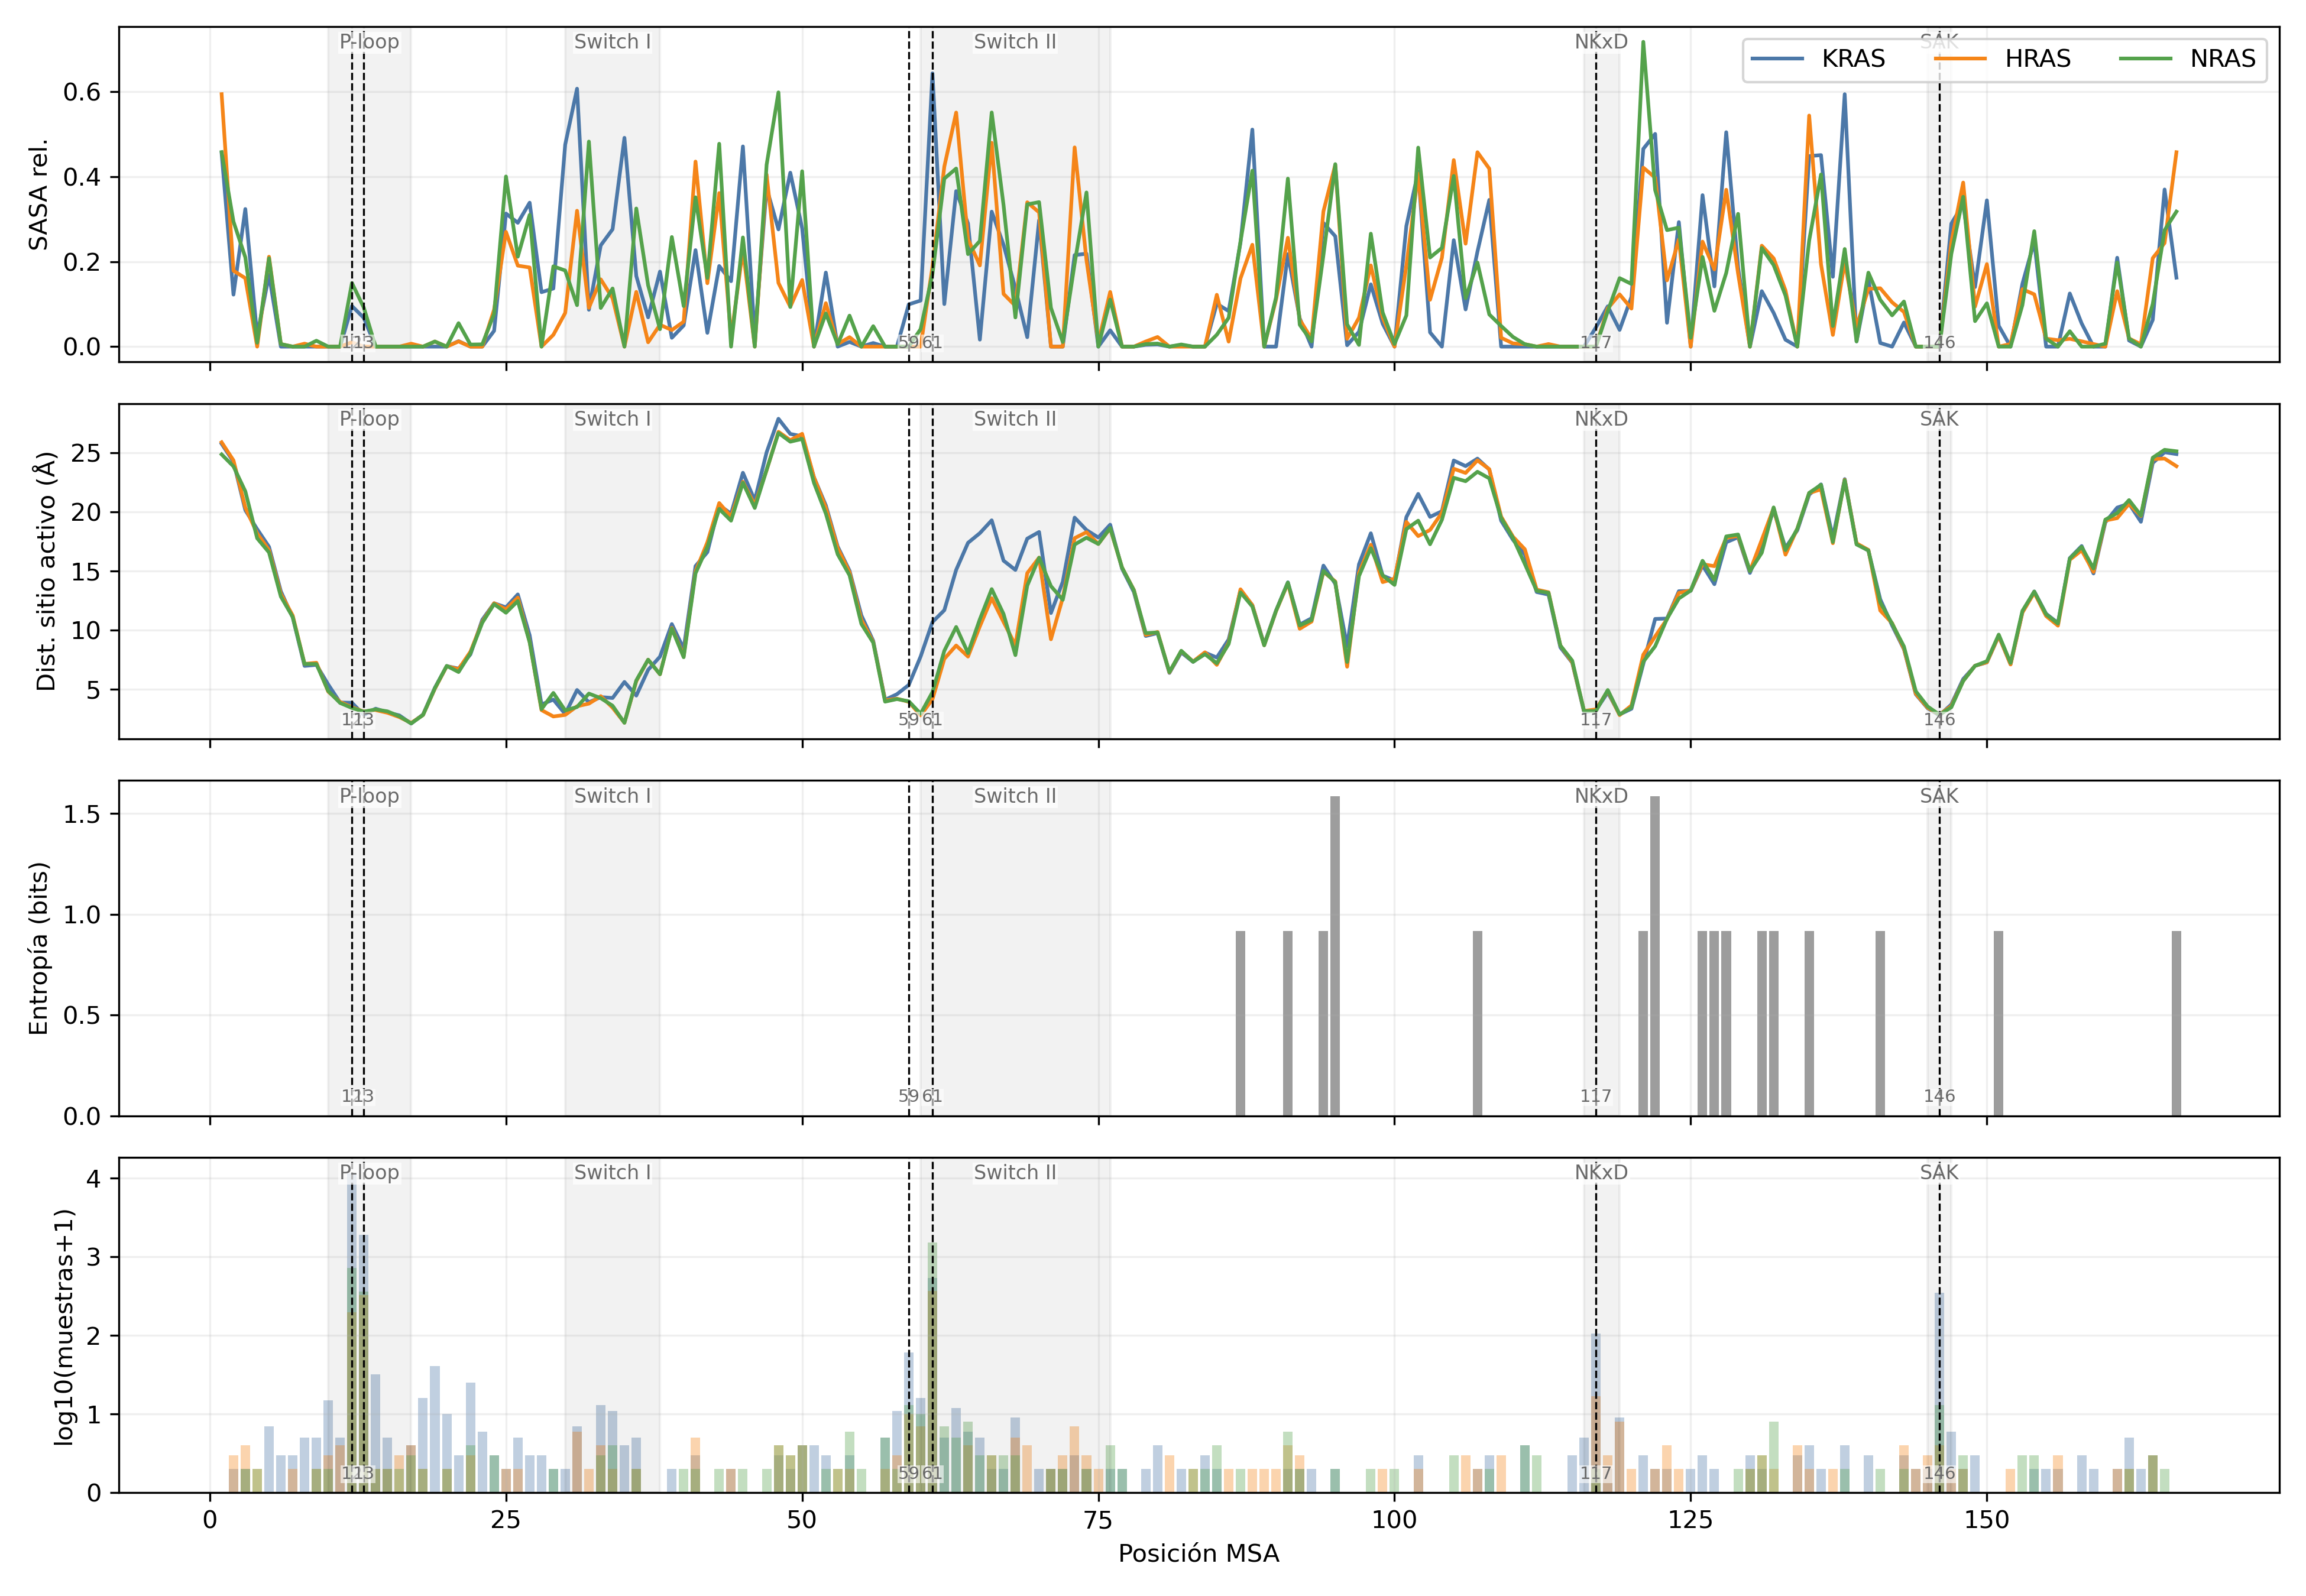

In [53]:
# ============================================================
# CHUNK 11.1: Figura de resumen de features estructurales
# ============================================================

# Ruta de salida para la figura.
figure_out = FIGURES_DIR / "03_features_overview.png"  

# plot_features_overview() genera una figura con múltiples paneles mostrando:
#   - Distribuciones de SASA por gen
#   - Perfil de distancia al sitio activo a lo largo de la secuencia
#   - Entropía de Shannon por posición
#   - Correlaciones entre features

print(f"Generando figura de resumen: {figure_out.name}")

# La función guarda la figura en output_path y devuelve la ruta guardada.
saved_path = plot_features_overview(master, figure_out)  # genera y guarda la figura

print(f"Figura guardada en: {saved_path}")
print(f"Tamaño del fichero: {figure_out.stat().st_size / 1024:.0f} KB")

# Mostramos la figura guardada directamente en el notebook.
from IPython.display import Image, display 
display(Image(filename=str(figure_out), width=900)) 

---
## 12. Resumen estadístico de la tabla maestra

In [54]:
# ============================================================
# CHUNK 12.1: Estadísticas descriptivas de las features
# ============================================================

print("=" * 50)
print("RESUMEN ESTADÍSTICO DE LA TABLA MAESTRA")
print("=" * 50)

# .describe() calcula estadísticas descriptivas básicas para todas las columnas numéricas:
#   count: número de valores no nulos
#   mean:  media aritmética
#   std:   desviación estándar
#   min:   valor mínimo
#   25%:   primer cuartil (Q1)
#   50%:   mediana (Q2)
#   75%:   tercer cuartil (Q3)
#   max:   valor máximo
#
# Usamos los nombres de MASTER_COLUMNS para las columnas numéricas de la tabla maestra:
numeric_cols = ["sasa_abs", "sasa_rel", "dist_active_site_angstrom", "shannon_entropy"] 

available_cols = [c for c in numeric_cols if c in master.columns]  # filtramos las que existen
desc_stats = master.loc[:, available_cols].describe().T.round(3)  # estadísticas transpuestas
print("\nEstadísticas descriptivas de features numéricas:")
print("-" * 87)
print(desc_stats.to_string()) 

print()

RESUMEN ESTADÍSTICO DE LA TABLA MAESTRA

Estadísticas descriptivas de features numéricas:
---------------------------------------------------------------------------------------
                           count    mean     std    min   25%     50%     75%      max
sasa_abs                   498.0  26.799  32.369  0.000  0.00  14.805  43.309  148.923
sasa_rel                   498.0   0.130   0.154  0.000  0.00   0.073   0.215    0.717
dist_active_site_angstrom  498.0  12.580   6.626  2.085  7.15  12.272  17.768   27.894
shannon_entropy            498.0   0.097   0.304 -0.000  0.00  -0.000  -0.000    1.585



In [55]:
# ============================================================
# CHUNK 12.2: Estadísticas por gen
# ============================================================

RAS_GENES = ("KRAS", "HRAS", "NRAS")
print("Estadísticas por gen (medias de features principales):")
print("-" * 70)

gene_stats = master.groupby("gene")[available_cols].mean().round(3)  # medias por gen
gene_stats = gene_stats.reindex(RAS_GENES)
print(gene_stats.to_string())  # mostramos tabla de medias por gen

print()

Estadísticas por gen (medias de features principales):
----------------------------------------------------------------------
      sasa_abs  sasa_rel  dist_active_site_angstrom  shannon_entropy
gene                                                                
KRAS    27.113     0.133                     12.973            0.097
HRAS    25.887     0.123                     12.384            0.097
NRAS    27.396     0.136                     12.383            0.097



In [56]:
# ============================================================
# CHUNK 12.3: Análisis de los hotspots en la tabla maestra
# ============================================================

print("Features de los hotspots oncogénicos en la tabla maestra:")
print("-" * 60)

# Filtramos la tabla maestra para mostrar solo las filas de los hotspots.
hotspot_mask = master["uniprot_position"].isin(hotspot_positions)
hotspot_rows = master.loc[hotspot_mask]

# Seleccionamos las columnas más informativas para el análisis de hotspots.
cols_to_show = [
    "gene",
    "uniprot_position",
    "aa_wt",
    "sasa_rel",
    "dist_active_site_angstrom",
    "shannon_entropy",
    "total_samples",
]

# Filtramos solo las columnas que existen en la tabla.
available_show = [c for c in cols_to_show if c in hotspot_rows.columns]

# Creamos una copia para evitar modificar el DataFrame original.
hotspot_display = hotspot_rows[available_show].copy()

# Definimos el orden deseado de los genes.
hotspot_display["gene"] = pd.Categorical(
    hotspot_display["gene"],
    categories=["KRAS", "HRAS", "NRAS"],
    ordered=True,
)

# Ordenamos primero por posición y después por gen.
hotspot_display = hotspot_display.sort_values(
    ["uniprot_position", "gene"]
)

# Mostramos la tabla sin índice.
print(hotspot_display.to_string(index=False))

print()
print("Interpretación esperada:")
print("  G12 y G13: sasa_rel < 0.25 (enterrados), dist_active_site < 5 Å (sitio activo), shannon_entropy ≈ 0 (conservados)")
print("  Q61: sasa_rel < 0.4 (semi-enterrado), dist_active_site < 10 Å (Switch II cerca del Mg2+), shannon_entropy ≈ 0")

Features de los hotspots oncogénicos en la tabla maestra:
------------------------------------------------------------
gene  uniprot_position aa_wt  sasa_rel  dist_active_site_angstrom  shannon_entropy  total_samples
KRAS                12     G  0.095456                   3.844901             -0.0          11564
HRAS                12     G  0.010302                   3.460250             -0.0            195
NRAS                12     G  0.149644                   3.406299             -0.0            728
KRAS                13     G  0.067692                   2.820925             -0.0           1917
HRAS                13     G  0.000000                   3.100715             -0.0            323
NRAS                13     G  0.091798                   3.093723             -0.0            364
KRAS                59     A  0.099373                   5.353804             -0.0             60
HRAS                59     A  0.000000                   3.927405             -0.0              9

In [57]:
# ============================================================
# CHUNK 12.4: Correlaciones entre features estructurales
# ============================================================

print("Matriz de correlación de Pearson entre features numéricas:")
print("-" * 90)

# La correlación de Pearson mide la relación lineal entre dos variables.
# Valores cercanos a +1 indican correlación positiva fuerte;
# valores cercanos a -1 indican correlación negativa fuerte;
# valores cercanos a 0 indican poca o ninguna correlación lineal.
#
# Expectativas biológicas:
#   - sasa_rel y dist_active_site_angstrom: correlación POSITIVA.
#     Los residuos cercanos al sitio activo tienden a estar más enterrados.
#   - sasa_rel y shannon_entropy: correlación POSITIVA.
#     Los residuos expuestos (alta SASA) suelen tolerar más variación.
#   - dist_active_site_angstrom y shannon_entropy: correlación POSITIVA.
#     Los residuos lejanos al sitio activo son menos críticos y más variables.
#
# available_cols contiene los nombres de MASTER_COLUMNS definidos en el chunk 12.1:
#   ["sasa_abs", "sasa_rel", "dist_active_site_angstrom", "shannon_entropy"]

# .corr() calcula la matriz de correlación de Pearson entre todas las columnas numéricas.
# method='pearson' es el valor por defecto (también existe 'spearman' y 'kendall').
if len(available_cols) > 1:  # solo calculamos si hay al menos 2 columnas numéricas
    corr_matrix = master[available_cols].corr(method="pearson").round(3)  # correlaciones
    print(corr_matrix.to_string())  # mostramos la matriz de correlación
else:
    print("  Insuficientes columnas numéricas para calcular correlaciones.")

print()

Matriz de correlación de Pearson entre features numéricas:
------------------------------------------------------------------------------------------
                           sasa_abs  sasa_rel  dist_active_site_angstrom  shannon_entropy
sasa_abs                      1.000     0.961                      0.321            0.292
sasa_rel                      0.961     1.000                      0.327            0.314
dist_active_site_angstrom     0.321     0.327                      1.000            0.134
shannon_entropy               0.292     0.314                      0.134            1.000



---
## Resumen del Hito 3

In [58]:
# ============================================================
# CHUNK 12.5: Resumen final del Hito 3
# ============================================================

print("\nFicheros generados:")

# Lista de todos los ficheros de salida del Hito 3.
output_files = [
    sasa_out,                              # SASA por residuo (3 genes)
    distance_out,                          # distancia al sitio activo (3 genes)
    conservation_out,                      # entropía de Shannon por posición MSA
    master_out,                            # tabla maestra (498 filas × N columnas)
    figure_out,                            # figura resumen de features
]

for path in output_files:  # iteramos sobre la lista de rutas de salida
    # .exists() verifica que el fichero existe en disco (el guardado fue exitoso).
    exists = path.exists()  # booleano: True si el fichero existe
    size_kb = path.stat().st_size / 1024 if exists else 0  # tamaño en KB (0 si no existe)
    status = "OK" if exists else "FALTA"  # estado del fichero
    print(f"  [{status}] {path.name}: {size_kb:.1f} KB")  # mostramos estado y tamaño

print("\nEstadísticas de la tabla maestra:")
print(f"  Filas totales: {len(master)} (166 posiciones × 3 genes)")  # 498 filas
print(f"  Columnas: {len(master.columns)}")  # número de features
print(f"  Genes: {sorted(master['gene'].unique().tolist())}")
# .unique() devuelve los valores únicos de una columna como array NumPy
# .tolist() convierte el array a lista Python estándar

print("\nFeaturas principales calculadas:")
print("  - SASA absoluta y relativa (Shrake-Rupley o DSSP)")
print("  - Distancia mínima de átomos pesados al sitio activo (GDP/GTP + Mg2+)")
print("  - Entropía de Shannon por columna del MSA (conservación evolutiva)")

print("\nVerificaciones biológicas:")
print("  - G12 está a < 5 Å del sitio activo en KRAS, HRAS y NRAS")
print("  - G12 tiene SASA_rel < 0.25 (residuo enterrado en el P-loop)")
print("  - Hotspots G12, G13, Q61, A146, K117 y A59 tienen entropía cercana a 0 (alta conservación)")

print("\nPróximo paso: Hito 4 — Anotación VEP (SIFT, PolyPhen, CADD)")
print("  → Notebook 04_vep_annotation.ipynb")


Ficheros generados:
  [OK] sasa_per_residue.csv: 19.6 KB
  [OK] distance_to_active_site.csv: 14.1 KB
  [OK] conservation_per_msa_position.csv: 2.5 KB
  [OK] master_features.csv: 40.3 KB
  [OK] 03_features_overview.png: 717.0 KB

Estadísticas de la tabla maestra:
  Filas totales: 498 (166 posiciones × 3 genes)
  Columnas: 12
  Genes: ['HRAS', 'KRAS', 'NRAS']

Featuras principales calculadas:
  - SASA absoluta y relativa (Shrake-Rupley o DSSP)
  - Distancia mínima de átomos pesados al sitio activo (GDP/GTP + Mg2+)
  - Entropía de Shannon por columna del MSA (conservación evolutiva)

Verificaciones biológicas:
  - G12 está a < 5 Å del sitio activo en KRAS, HRAS y NRAS
  - G12 tiene SASA_rel < 0.25 (residuo enterrado en el P-loop)
  - Hotspots G12, G13, Q61, A146, K117 y A59 tienen entropía cercana a 0 (alta conservación)

Próximo paso: Hito 4 — Anotación VEP (SIFT, PolyPhen, CADD)
  → Notebook 04_vep_annotation.ipynb
